# Влияние рекламной кампании на конверсию в покупку: A/B-тест
## 📌 Бизнес-задача

Компания запустила рекламную кампанию (группа `ad`) и сравнивает её с контрольной группой, которой показывали нейтральное социальное сообщение (`psa`). Определить, приводит ли реклама к изменению конверсии в покупку, оценить размер и статистическую неопределённость эффекта и определить дальнейшие действия на основе результатов эксперимента.

## 🎯 Аналитические вопросы

Цель данного проекта — ответить на следующие вопросы:
1. Какой минимальный эффект способен обнаружить фактический размер выборки?
2. Валиден ли сам эксперимент — нет ли перекоса в разбиении групп или в сопутствующих признаках?
3. Статистически значимо ли реклама увеличивает конверсию по сравнению с контрольной группой?
4. Насколько велик эффект в абсолютном и относительном выражении — практическая значимость?
5. Как связана конверсия с интенсивностью рекламных показов и другими характеристиками аудитории?
6. Одинаков ли эффект в разных сегментах (день недели, час показа)?
7. Какую рекомендацию дать бизнесу?

## 📊 Набор данных

[Marketing A/B Testing](https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing) (Kaggle) — данные эксперимента по показу рекламы. 588 101 пользователь, без пропусков и дубликатов.

**Поля:**
- `user id` — идентификатор пользователя
- `test group` — группа: `ad` (реклама) или `psa` (контроль, социальное сообщение)
- `converted` — совершил ли пользователь покупку (bool)
- `total ads` — число показанных пользователю объявлений
- `most ads day` — день недели с наибольшим числом показов
- `most ads hour` — час с наибольшим числом показов

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest, confint_proportions_2indep
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association
from statsmodels.stats.multitest import multipletests

pd.set_option('display.max_columns', None)
import statsmodels.formula.api as smf

# 1. Дизайн эксперимента

**Гипотезы:**

- H0: конверсия в группе `ad` равна конверсии в группе `psa` (реклама не влияет на конверсию)
- H1: конверсия в группе `ad` отличается от конверсии в группе `psa`
  
Основная метрика эксперимента — **conversion rate**, то есть доля пользователей, совершивших покупку.

Уровень значимости: **α = 0.05**.

Для основного теста используется двусторонняя гипотеза.

### Экспериментальные группы

- **`ad`** — пользователи, которым показывалась рекламная кампания.
- **`psa`** — контрольная группа, которой вместо рекламы показывалось социальное сообщение (PSA).

Сравниваемая метрика — доля пользователей, совершивших покупку.

# 2. Загрузка и обзор данных

In [2]:
df = pd.read_csv('marketing_AB.csv')

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [9]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [10]:
df.shape

(588101, 6)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   user id        588101 non-null  int64
 1   test group     588101 non-null  str  
 2   converted      588101 non-null  bool 
 3   total ads      588101 non-null  int64
 4   most ads day   588101 non-null  str  
 5   most ads hour  588101 non-null  int64
dtypes: bool(1), int64(3), str(2)
memory usage: 23.0 MB


In [12]:
df['user id'].duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.rename(columns={'user id': 'user_id',
         'test group': 'test_group',
         'total ads': 'total_ads',
         'most ads day': 'most_ads_day',
         'most ads hour': 'most_ads_hour'})

In [16]:
df['test_group'] = df['test_group'].astype('category')
df['converted'] = df['converted'].astype('int')

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   user_id        588101 non-null  int64   
 1   test_group     588101 non-null  category
 2   converted      588101 non-null  int64   
 3   total_ads      588101 non-null  int64   
 4   most_ads_day   588101 non-null  str     
 5   most_ads_hour  588101 non-null  int64   
dtypes: category(1), int64(4), str(1)
memory usage: 23.0 MB


In [18]:
df['test_group'].value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [19]:
df['test_group'].value_counts(normalize=True).mul(100).round(2)

test_group
ad     96.0
psa     4.0
Name: proportion, dtype: float64

# 3. Проверка валидности эксперимента

### Распределение экспериментальных групп

In [20]:
group_counts = df['test_group'].value_counts()
group_share = df['test_group'].value_counts(normalize=True).mul(100).round(2)

display(group_counts)
display(group_share)

test_group
ad     564577
psa     23524
Name: count, dtype: int64

test_group
ad     96.0
psa     4.0
Name: proportion, dtype: float64

В эксперименте 564,577 пользователей относятся к группе `ad` (96.0%), а 23,524 — к контрольной группе `psa` (4.0%).
Таким образом, группы существенно несбалансированы по размеру.

### Мощность теста при фактическом соотношении групп

Посчитаем, какой минимальный эффект (MDE) можно обнаружить на **реальных** размерах групп при α = 0.05 и мощности 80%.

In [21]:
n_ad = (df['test_group'] == 'ad').sum()
n_psa = (df['test_group'] == 'psa').sum()

# минимальный размер эффекта (Cohen's h), обнаруживаемый на реальных размерах групп
h = NormalIndPower().solve_power(nobs1=n_psa, alpha=0.05, power=0.80, ratio=n_ad / n_psa)

# переводим Cohen's h обратно в конверсию
cr_detectable = np.sin(np.arcsin(np.sqrt(cr_psa)) + h / 2) ** 2
mde_abs = cr_detectable - cr_psa

print(f'Реальный MDE: {mde_abs:.2%} (абсолютный), {mde_abs / cr_psa:.0%} (относительный)')

Реальный MDE: 0.26% (абсолютный), 14% (относительный)


### Балансировка сопутствующих признаков между группами

In [22]:
contingency = pd.crosstab(df['test_group'], df['most_ads_day'])
chi2, p, *_ = chi2_contingency(contingency)
cramers_v = association(contingency, method='cramer')
print(f'most_ads_day: p-value={p:.6f}, Cramér\'s V={cramers_v:.4f}')

contingency = pd.crosstab(df['test_group'], df['most_ads_hour'])
chi2, p, *_ = chi2_contingency(contingency)
cramers_v = association(contingency, method='cramer')
print(f'most_ads_hour: p-value={p:.6f}, Cramér\'s V={cramers_v:.4f}')

most_ads_day: p-value=0.000000, Cramér's V=0.0200
most_ads_hour: p-value=0.000000, Cramér's V=0.0181


Пересечений пользователей между группами не обнаружено. Балансировка сопутствующих признаков (день и час 
показа) подтверждает корректность рандомизации: хотя p-value статистически значим в обоих случаях 
(p<0.001)  — размер эффекта пренебрежимо мал. Распределение времени показа не связано с принадлежностью 
к группе, эксперимент валиден.

# 4. Основной тест

In [23]:
df.groupby('test_group')['converted'].agg(['mean', 'count'])

,mean,count
test_group,,
ad,0.025547,564577
psa,0.017854,23524


In [24]:
ad_converted = df.query("test_group == 'ad'")['converted'].sum()
ad_total = df.query("test_group == 'ad'")['converted'].count()
psa_converted = df.query("test_group == 'psa'")['converted'].sum()
psa_total = df.query("test_group == 'psa'")['converted'].count()

In [25]:
z_stat, p_value = proportions_ztest([ad_converted, psa_converted], [ad_total, psa_total])

In [26]:
print(f'z-statistic: {z_stat:.3f}')
print(f'p-value: {p_value:.10f}')

z-statistic: 7.370
p-value: 0.0000000000


In [27]:
ci_low, ci_upp = confint_proportions_2indep(ad_converted, ad_total, psa_converted, psa_total)
print(f'95% ДИ разницы конверсий (ad - psa): [{ci_low:.2%}, {ci_upp:.2%}]')

95% ДИ разницы конверсий (ad - psa): [0.59%, 0.94%]


In [28]:
abs_diff = (ad_converted/ad_total) - (psa_converted/psa_total)
rel_diff = abs_diff / (psa_converted/psa_total) * 100

print(f'Абсолютная разница: {abs_diff:.4%}')
print(f'Относительный прирост: {rel_diff:.1f}%')

Абсолютная разница: 0.7692%
Относительный прирост: 43.1%


Конверсия в группе `ad` (2,55%) статистически значимо выше, чем в группе `psa` (1,79%) 
(z-тест пропорций, p < 0.0001). 95% доверительный интервал разницы конверсий: [0.59%,0.94%] — 
не захватывает ноль. Абсолютный прирост составляет 0,77 п.п., относительный — около 43%. 

### Проверим надежность результата бутстрепом

In [29]:
ad = df[df['test_group'] == 'ad']['converted'].values
psa = df[df['test_group'] == 'psa']['converted'].values

n_boot = 5000
boot_diffs = []

for _ in range(n_boot):
    ad_sample = np.random.choice(ad, size=len(ad), replace=True)
    psa_sample = np.random.choice(psa, size=len(psa), replace=True)

    boot_diffs.append(ad_sample.mean() - psa_sample.mean())
    
boot_diffs = np.array(boot_diffs)
ci_low_boot, ci_up_boot = np.percentile(boot_diffs, [2.5, 97.5])

In [30]:
print(f'Бутстреп 95% ДИ разницы конверсий: [{ci_low_boot:.2%}, {ci_up_boot:.2%}]')

Бутстреп 95% ДИ разницы конверсий: [0.60%, 0.94%]


Text(0.5, 0, 'Разница конверсий')

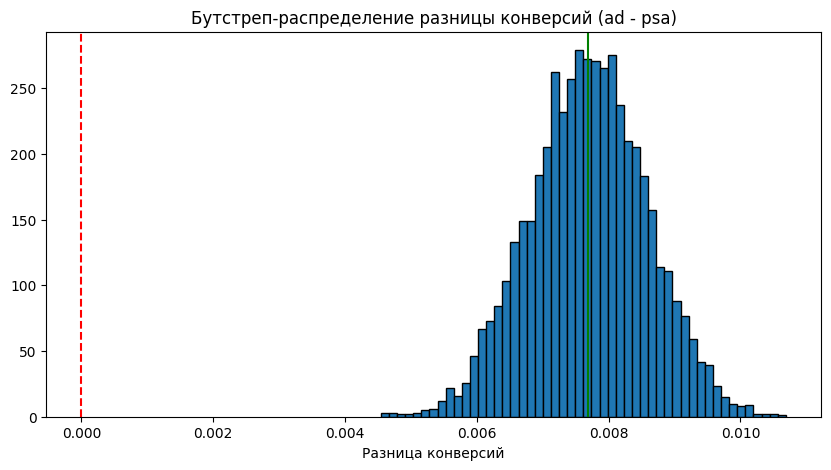

In [31]:
plt.figure(figsize=(10, 5))
plt.hist(boot_diffs, bins=50, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Нет эффекта (0)')
plt.axvline(abs_diff, color='green', linestyle='-', label='Наблюдаемая разница')
plt.title('Бутстреп-распределение разницы конверсий (ad - psa)')
plt.xlabel('Разница конверсий')

Для независимой проверки аналитического ДИ 
построено бутстреп-распределение разницы конверсий (5 000 итераций). Бутстреп 95% ДИ: 0.59%, 0.95% — практически совпадает с аналитическим ДИ z-теста, что подтверждает надёжность результата.

# 5. Guardrail-метрики и проверка на побочные факторы

### Связь конверсии с интенсивностью показов

In [32]:
df['total_ads'].describe()

count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total_ads, dtype: float64

In [33]:
df.groupby('converted')['total_ads'].median()

converted
0    13.0
1    64.0
Name: total_ads, dtype: float64

Распределение total_ads сильно скошено, поэтому выполним тест манна-уитни, для того чтобы проверить значимость покупок от просмотра рекламы.

In [34]:
stats.mannwhitneyu(
    df.query('converted == 1')['total_ads'],
    df.query('converted == 0')['total_ads'],
    alternative='two-sided'
)

MannwhitneyuResult(statistic=np.float64(7269106736.0), pvalue=np.float64(0.0))

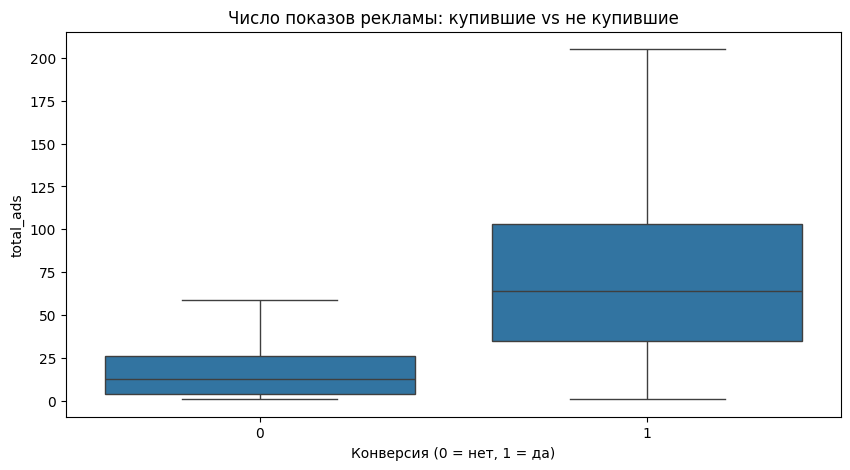

In [35]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='converted', y='total_ads', data=df, showfliers=False)
plt.title('Число показов рекламы: купившие vs не купившие')
plt.xlabel('Конверсия (0 = нет, 1 = да)')
plt.ylabel('total_ads')
plt.show()

In [36]:
df.groupby('test_group')['total_ads'].median()

test_group
ad     13.0
psa    12.0
Name: total_ads, dtype: float64

In [37]:
df['ads_bin'] = pd.qcut(df['total_ads'], 4, duplicates='drop')

result = (
    df.groupby(['ads_bin', 'test_group'], observed=True)['converted']
      .mean()
      .unstack() * 100
)
result

test_group,ad,psa
ads_bin,,
"(0.999, 4.0]",0.236019,0.197508
"(4.0, 13.0]",0.513256,0.631334
"(13.0, 27.0]",1.186328,1.251422
"(27.0, 2065.0]",8.354553,5.363781


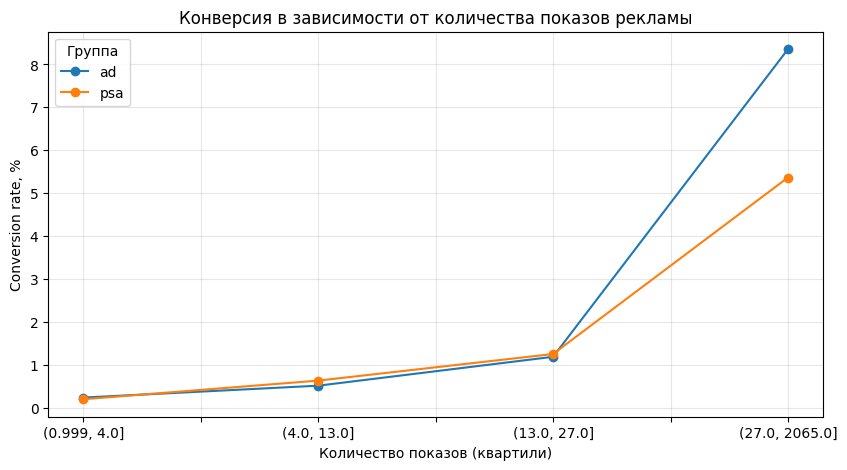

In [38]:
result.plot(
    kind='line',
    marker='o',
    figsize=(10, 5)
)

plt.title('Конверсия в зависимости от количества показов рекламы')
plt.xlabel('Количество показов (квартили)')
plt.ylabel('Conversion rate, %')
plt.legend(title='Группа')
plt.grid(alpha=0.3)
plt.show()

Количество рекламных показов связано с фактом покупки: медианное число показов у купивших пользователей составило 64 против 13 у некупивших (тест Манна — Уитни, p < 0,0001). При этом данная связь не доказывает причинное влияние количества показов на покупку.

Медианное количество показов в группах ad и psa было сопоставимым: 13 и 12 соответственно.

При анализе по квартилям количества показов статистически значимая разница конверсий между ad и psa обнаружена только в верхнем квартиле: 8,36% против 5,36% (p < 0,0001). В остальных квартилях статистически значимых различий не выявлено.

**Итог:** наблюдаемый эффект рекламы может быть выражен сильнее среди пользователей с большим количеством показов. Однако этот анализ не позволяет утверждать, что высокая частота показов является причиной роста конверсии. Результаты по квартилям следует считать дополнительными исследовательскими наблюдениями, а не окончательным доказательством того, что реклама эффективна только при высокой интенсивности показов.


# 6. Сегментный анализ

In [39]:
day_stats = df.groupby(['most_ads_day', 'test_group'], observed=True)['converted'].agg(['mean', 'count']).reset_index()
day_stats['mean'] = (day_stats['mean'] * 100).round(2)
day_stats.head()

,most_ads_day,test_group,mean,count
0,Friday,ad,2.25,88805
1,Friday,psa,1.63,3803
2,Monday,ad,3.32,83571
3,Monday,psa,2.26,3502
4,Saturday,ad,2.13,78802


In [40]:
hour_stats = df.groupby(['most_ads_hour', 'test_group'], observed=True)['converted'].agg(['mean', 'count']).reset_index()
hour_stats['mean'] = (hour_stats['mean'] * 100).round(2)
hour_stats.head()

,most_ads_hour,test_group,mean,count
0,0,ad,1.92,5309
1,0,psa,0.00,227
2,1,ad,1.34,4615
3,1,psa,0.00,187
4,2,ad,0.76,5152


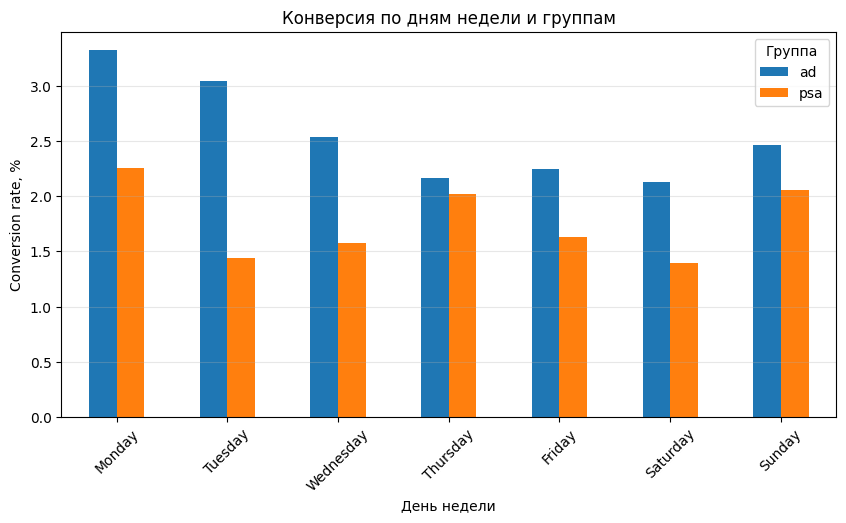

In [41]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot_day = df.groupby(['most_ads_day', 'test_group'], observed=True)['converted'].mean().unstack() * 100
pivot_day = pivot_day.loc[days]

pivot_day.plot(kind='bar', figsize=(10, 5))
plt.title('Конверсия по дням недели и группам')
plt.xlabel('День недели')
plt.ylabel('Conversion rate, %')
plt.xticks(rotation=45)
plt.legend(title='Группа')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [42]:
def segment_test(df, col):
    rows = []

    for val, sub in df.groupby(col, observed=True):
        g = sub.groupby('test_group', observed=True)['converted'].agg(['sum', 'count'])
        if set(g.index) != {'ad', 'psa'}:
            continue
        z, p = proportions_ztest(g.loc[['ad', 'psa'], 'sum'], g.loc[['ad', 'psa'], 'count'])
        cr = g['sum'] / g['count']
        rows.append({col: val,
                    'ad_n': g.loc['ad', 'count'],
                    'psa_n': g.loc['psa', 'count'],
                    'cr_ad_%': cr['ad']*100,
                    'cr_psa_%': cr['psa']*100,
                    'diff_pp': (cr['ad'] - cr['psa'])*100,
                    'p_value': p})
        
    res = pd.DataFrame(rows)
    res['p_holm'] = multipletests(res['p_value'], method='holm')[1]
    res['significant'] = res['p_holm'] < 0.05

    return res.round(4)

In [43]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_res = segment_test(df, 'most_ads_day').set_index('most_ads_day').loc[days].reset_index()
day_res

,most_ads_day,ad_n,psa_n,cr_ad_%,cr_psa_%,diff_pp,p_value,p_holm,significant
0,Monday,83571,3502,3.3241,2.2559,1.0683,0.0005,0.0025,True
1,Tuesday,74572,2907,3.0440,1.4448,1.5992,0.0000,0.0000,True
2,Wednesday,77418,3490,2.5356,1.5759,0.9597,0.0004,0.0023,True
3,Thursday,79077,3905,2.1637,2.0230,0.1407,0.5548,0.5548,False
4,Friday,88805,3803,2.2465,1.6303,0.6162,0.0116,0.0347,True
5,Saturday,78802,2858,2.1307,1.3996,0.7311,0.0075,0.0299,True
6,Sunday,82332,3059,2.4620,2.0595,0.4025,0.1572,0.3144,False


**Выводы по дням недели.** После поправки Холма на множественные сравнения разница между `ad` и `psa` значима в 5 из 7 дней (понедельник, вторник, среда, пятница, суббота). В четверг (+0,14 п.п.) и воскресенье (+0,40 п.п.) значимого эффекта не обнаружено. Размер эффекта сильно различается: от +0,14 п.п. (четверг) до +1,60 п.п. (вторник).

Важная оговорка: в контрольной группе в каждом дне всего около 3 000 пользователей, поэтому оценки по отдельным дням шумные. Незначимость в четверг и воскресенье **не доказывает**, что реклама в эти дни не работает: возможно, не хватает данных. Различается ли эффект по дням на самом деле, проверяет тест взаимодействия ниже.

### Сегментный анализ по часам показа

In [44]:
hour_res = segment_test(df, 'most_ads_hour')
hour_res

,most_ads_hour,ad_n,psa_n,cr_ad_%,cr_psa_%,diff_pp,p_value,p_holm,significant
0,0,5309,227,1.9213,0.0000,1.9213,0.0350,0.6308,False
1,1,4615,187,1.3434,0.0000,1.3434,0.1106,1.0000,False
2,2,5152,181,0.7570,0.0000,0.7570,0.2401,1.0000,False
3,3,2590,89,1.0425,1.1236,-0.0811,0.9410,1.0000,False
4,4,694,28,1.5850,0.0000,1.5850,0.5020,1.0000,False
5,5,742,23,2.1563,0.0000,2.1563,0.4766,1.0000,False
6,6,1985,83,2.3174,0.0000,2.3174,0.1607,1.0000,False
7,7,6168,237,1.8482,0.8439,1.0044,0.2552,1.0000,False
8,8,16968,659,1.9861,1.0622,0.9239,0.0925,1.0000,False
9,9,29802,1202,1.9529,1.0815,0.8714,0.0309,0.5864,False


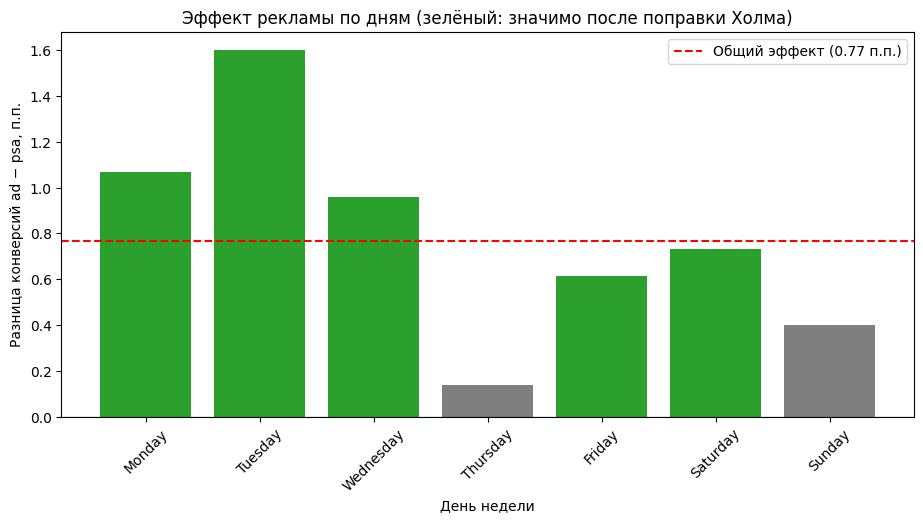

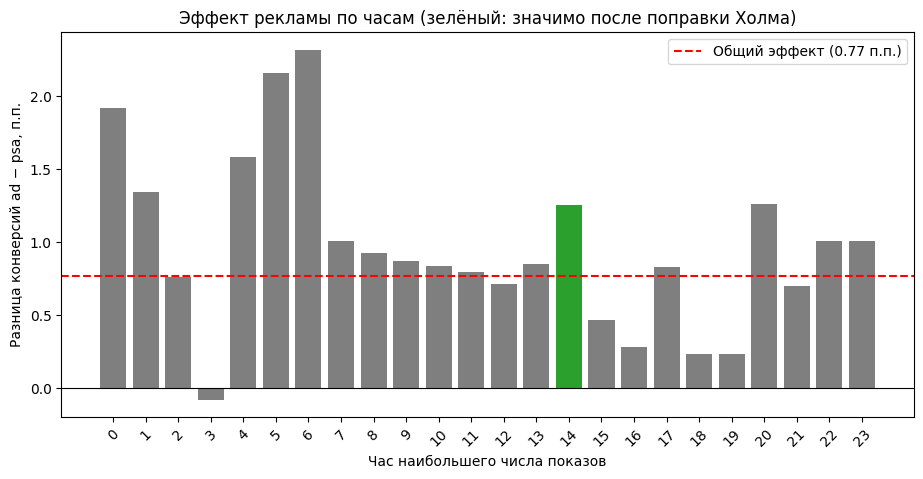

In [45]:
def plot_effect(res, col, title, xlabel):
    """Разница конверсий ad - psa по сегментам. Зелёные столбцы: значимо после поправки Холма."""
    colors = res['significant'].map({True: 'tab:green', False: 'tab:gray'})
    plt.figure(figsize=(11, 5))
    plt.bar(res[col].astype(str), res['diff_pp'], color=colors)
    plt.axhline(0, color='black', lw=0.8)
    plt.axhline(abs_diff * 100, color='red', ls='--', label=f'Общий эффект ({abs_diff * 100:.2f} п.п.)')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Разница конверсий ad − psa, п.п.')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

plot_effect(day_res, 'most_ads_day', 'Эффект рекламы по дням (зелёный: значимо после поправки Холма)', 'День недели')
plot_effect(hour_res, 'most_ads_hour', 'Эффект рекламы по часам (зелёный: значимо после поправки Холма)', 'Час наибольшего числа показов')

**Выводы по часам.** После поправки Холма значим только один час из 24: 14:00 (+1,25 п.п., p с поправкой = 0,032). При этом эффект положителен в 23 из 24 часов (исключение: 03:00, −0,08 п.п., при очень малой выборке). Остальные часы «не значимы» в первую очередь из-за малого размера контрольной группы: в часах 0–7 в `psa` меньше 300 пользователей (от 23 до 237), а в часах 0, 1, 2, 4, 5, 6 в `psa` нет ни одной покупки. Результаты по этим часам ненадёжны, делать по ним выводы нельзя.

### Различается ли эффект между сегментами? Тест взаимодействия

Отдельные тесты по сегментам отвечают на вопрос «значим ли эффект в этом сегменте», но не на вопрос «отличается ли эффект между сегментами». Для этого сравниваем две логистические модели:

- **модель без взаимодействия**: эффект рекламы одинаков во всех сегментах;
- **модель со взаимодействием**: у каждого сегмента свой эффект.

LR-тест проверяет, объясняет ли вторая модель данные лучше, чем можно ожидать от случайности. Часы объединены в 4 периода суток, так как в отдельных часах у `psa` слишком мало пользователей (в некоторых нет ни одной покупки), и модель по 24 часам нестабильна.

In [46]:
df['hour_part'] = pd.cut(df['most_ads_hour'], bins=[-1, 5, 11, 17, 23],
                         labels=['ночь 0-5', 'утро 6-11', 'день 12-17', 'вечер 18-23'])

def interaction_test(df, segment):
    """LR-тест: зависит ли эффект рекламы от сегмента."""
    m0 = smf.logit(f'converted ~ C(test_group) + C({segment})', df).fit(disp=0)
    m1 = smf.logit(f'converted ~ C(test_group) * C({segment})', df).fit(disp=0)
    lr = 2 * (m1.llf - m0.llf)
    dof = m1.df_model - m0.df_model
    return lr, dof, stats.chi2.sf(lr, dof)

for segment in ['most_ads_day', 'hour_part']:
    lr, dof, p = interaction_test(df, segment)
    print(f'группа × {segment}: LR = {lr:.2f}, степеней свободы = {dof:.0f}, p-value = {p:.4f}')

группа × most_ads_day: LR = 16.22, степеней свободы = 6, p-value = 0.0126
группа × hour_part: LR = 10.80, степеней свободы = 3, p-value = 0.0128


In [47]:
hour_part_res = segment_test(df, 'hour_part')
hour_part_res

,hour_part,ad_n,psa_n,cr_ad_%,cr_psa_%,diff_pp,p_value,p_holm,significant
0,ночь 0-5,19102,735,1.3454,0.1361,1.2094,0.0045,0.0045,True
1,утро 6-11,136526,5727,2.1161,1.2572,0.8589,0.0000,0.0000,True
2,день 12-17,246925,10914,2.7668,2.0158,0.7511,0.0000,0.0000,True
3,вечер 18-23,162024,6148,2.7434,2.0657,0.6777,0.0013,0.0027,True


**Вывод по взаимодействию.** Тест взаимодействия отвергает гипотезу об одинаковом эффекте: p = 0,0126 для дней недели и p = 0,0128 для периодов суток (оба результата остаются значимыми и при поправке Бонферрони на два теста, порог 0,025). То есть эффект рекламы **различается между сегментами**, но различие умеренное (p порядка 0,01, а не 0,0001).

Интерпретировать это нужно осторожно:
- Тест работает в шкале логарифма шансов, то есть сравнивает **относительные** эффекты. В абсолютных единицах эффект по периодам суток довольно стабилен: ночь +1,21, утро +0,86, день +0,75, вечер +0,68 п.п.
- Сильнее всего выделяется ночь: конверсия в `psa` там всего 0,14% при 735 пользователях (в `ad` 1,35%). Такая малая база резко увеличивает относительный эффект и, вероятно, во многом создаёт найденное «взаимодействие».
- По дням эффект максимален во вторник (+1,60 п.п.) и минимален в четверг (+0,14 п.п.), но объяснить причину по этим данным нельзя.

Вывод: эффект положителен везде, но его размер зависит от сегмента. Причины различий и пригодность сегментов для таргетинга нужно проверять отдельным экспериментом.

# 7. Ключевые выводы и рекомендации

## Находки

1. **Эксперимент валиден по сопутствующим признакам**, но группы сильно несбалансированы (96% `ad` / 4% `psa`). При таких размерах групп минимально обнаруживаемый эффект составляет 0,26 п.п. (14% относительных), что заметно меньше наблюдаемых +0,77 п.п., то есть мощности достаточно.
2. **Реклама значимо повышает конверсию:** 2,55% в `ad` против 1,79% в `psa`. Абсолютный прирост +0,77 п.п. (95% ДИ: [0,59; 0,94] п.п.), относительный около +43%. Бутстреп-интервал практически совпадает с аналитическим.
3. **Конверсия связана с интенсивностью показов.** Покупатели видели в среднем гораздо больше рекламы (медиана 64 против 13 показов). Заметный эффект рекламы наблюдается в верхнем квартиле по числу показов (8,36% против 5,36%), но это корреляция: показы нельзя считать причиной покупки.
4. **По дням недели** эффект положителен во все дни и значим после поправки Холма в 5 из 7 дней (максимум во вторник, +1,60 п.п.; в четверг и воскресенье значимого эффекта нет).
5. **По часам и периодам суток** эффект положителен в 23 из 24 часов, значим после поправки только в 14:00. Тест взаимодействия показывает, что размер эффекта зависит от дня и времени суток (p ≈ 0,013), но различие умеренное и частично объясняется малой контрольной группой в ночные часы.

## Рекомендация

**Запускать кампанию.** Эффект статистически и практически значим, а его знак положителен во всех днях недели и в 23 из 24 часов. Перед масштабированием оценить экономику: прирост конверсии (+0,77 п.п.) нужно сопоставить со стоимостью рекламных показов и средним чеком. Таргетинг по дням и часам на основании этих данных не рекомендуется: сегментный анализ исследовательский, а контрольная группа в сегментах мала. Если нужен таргетинг, проверять его отдельным экспериментом с более крупным контролем. Частоту показов тоже стоит тестировать отдельно.

## Ограничения анализа

- Контроль — это PSA (нейтральное сообщение), а не отсутствие рекламы: оценивается эффект рекламы относительно PSA.
- Группы несбалансированы (96/4); замысел разбиения в датасете не документирован, поэтому проверку на SRM (sample ratio mismatch) провести нельзя.
- Нет данных о выручке и стоимости рекламы, поэтому ROI оценить нельзя; метрика только бинарная конверсия.
- Неизвестна длительность эксперимента, эффект новизны исключить нельзя.
- `total_ads`, `most_ads_day` и `most_ads_hour` измерены после начала воздействия, поэтому сегментный анализ исследовательский.
- Сегментные результаты по дням и часам получены на небольшой контрольной группе в каждом сегменте и менее надёжны, чем общий результат.